# Model Tuning

In this notebook, we will tune the model for the best performance. Therefore, we will do a hyperparameter tuning using the following approach:

1. Grid Search
2. Random Search
3. Bayesian Optimization

The best dataset cleanup strategy and model was already evaluated in the previous notebook. The best Algorithm was Random Forest as described in `Model_Dataset_Building&Evaluation.ipynb`. The best data strategy was used in `data/interim/strict_forecasting/lpd_terrestrial_strict_last2020_unitsdirect_global_zeros_not_heavy.csv`.

## The following hyperparameters will be tuned:

- n_estimators
- max_depth
- min_samples_split
- min_samples_leaf
- max_features
- bootstrap
- random_state

## 1. Imports and settings

In [10]:
from pathlib import Path
import warnings
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

DATA_PATH = Path("../data/interim/strict_forecasting/lpd_terrestrial_strict_last2020_unitsdirect_global_zeros_not_heavy.csv")

N_LAGS = 4
TEST_YEARS = 5
RANDOM_STATE = 42

print(f"Dataset: {DATA_PATH.name}")
print(f"Lags:    {N_LAGS}")
print(f"Test years: {TEST_YEARS}")

Dataset: lpd_terrestrial_strict_last2020_unitsdirect_global_zeros_not_heavy.csv
Lags:    4
Test years: 5


## 2. Data loading and preprocessing helpers

The same pipeline from `Model_Dataset_Building&Evaluation.ipynb` is reused here to ensure consistency.

In [11]:
df_raw = pd.read_csv(DATA_PATH)

reference_columns = list(df_raw.columns)
year_columns = [col for col in reference_columns if str(col).isdigit()]

static_numeric_features = ["latitude", "longitude"]
static_categorical_features = [
    "class", "family", "ipbes_subregion", "system_group", "t_realm", "t_biome", "units"
]
identifier_columns = ["id", "binomial", "common_name", "location", "country"]

ref_set = set(reference_columns)
static_numeric_features     = [c for c in static_numeric_features     if c in ref_set]
static_categorical_features = [c for c in static_categorical_features if c in ref_set]
identifier_columns          = [c for c in identifier_columns          if c in ref_set]


def build_series_id(df):
    parts = []
    if "common_name" in df.columns:
        parts.append(df["common_name"].astype(str))
    elif "binomial" in df.columns:
        parts.append(df["binomial"].astype(str))
    if "country" in df.columns:
        parts.append(df["country"].astype(str))
    if not parts:
        return pd.Series(np.arange(len(df)).astype(str), index=df.index)
    series_id = parts[0]
    for p in parts[1:]:
        series_id = series_id + "|" + p
    return series_id


def wide_to_long(df):
    id_columns = [col for col in df.columns if col not in year_columns]
    long_df = df.melt(
        id_vars=id_columns,
        value_vars=year_columns,
        var_name="Year",
        value_name="Population"
    ).dropna(subset=["Population"]).copy()
    long_df["Year"] = long_df["Year"].astype(int)
    long_df["series_id"] = build_series_id(long_df)
    long_df["log_population"] = np.log1p(long_df["Population"])
    return long_df


def add_lag_features(long_df, n_lags=4):
    long_df = long_df.sort_values(["series_id", "Year"]).copy()
    grouped_pop = long_df.groupby("series_id")["Population"]

    for lag in range(1, n_lags + 1):
        long_df[f"lag_{lag}"] = grouped_pop.shift(lag)

    long_df["prev_year"]         = long_df.groupby("series_id")["Year"].shift(1)
    long_df["year_gap_from_prev"] = long_df["Year"] - long_df["prev_year"]
    long_df["rolling_mean_3"] = (
        grouped_pop.shift(1).rolling(3).mean().reset_index(level=0, drop=True)
    )
    long_df["rolling_std_3"] = (
        grouped_pop.shift(1).rolling(3).std().reset_index(level=0, drop=True)
    )
    long_df["population_difference"]  = long_df["lag_1"] - long_df["lag_2"]
    long_df["population_growth_rate"] = (
        (long_df["lag_1"] - long_df["lag_2"]) / long_df["lag_2"].replace(0, np.nan)
    ).replace([np.inf, -np.inf], np.nan)

    needed = [f"lag_{lag}" for lag in range(1, n_lags + 1)]
    long_df = long_df.dropna(subset=needed).copy()
    return long_df


def temporal_split(df, test_years=5):
    years = sorted(df["Year"].unique())
    test_year_values = years[-test_years:]
    train_df = df[df["Year"] <  min(test_year_values)].copy().reset_index(drop=True)
    test_df  = df[df["Year"].isin(test_year_values)].copy().reset_index(drop=True)
    return train_df, test_df, test_year_values


def evaluate(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mean_abs_true = np.mean(np.abs(y_true))
    nmae = mae / mean_abs_true if mean_abs_true != 0 else np.nan
    denom = np.sum(np.abs(y_true))
    wape  = np.sum(np.abs(y_true - y_pred)) / denom if denom != 0 else np.nan
    smape_denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    valid = smape_denom != 0
    smape = np.mean(np.abs(y_true[valid] - y_pred[valid]) / smape_denom[valid]) if np.any(valid) else np.nan
    return {"MAE": mae, "RMSE": rmse, "NMAE": nmae, "WAPE": wape, "sMAPE": smape}


print("Helpers defined.")

Helpers defined.


## 3. Prepare modeling data and build preprocessor

In [12]:
long_df = wide_to_long(df_raw)
long_df = add_lag_features(long_df, n_lags=N_LAGS)

numeric_features = (
    ["Year"]
    + [f"lag_{i}" for i in range(1, N_LAGS + 1)]
    + ["year_gap_from_prev", "rolling_mean_3", "rolling_std_3",
       "population_difference", "population_growth_rate"]
    + static_numeric_features
)
categorical_features = static_categorical_features
feature_columns = numeric_features + categorical_features

model_columns = []
for col in ["Year", "Population", "log_population"] + feature_columns:
    if col not in model_columns:
        model_columns.append(col)

model_df = long_df[model_columns].copy()
train_df, test_df, test_year_values = temporal_split(model_df, test_years=TEST_YEARS)

X_train = train_df[feature_columns]
y_train = train_df["log_population"]
X_test  = test_df[feature_columns]
y_test  = test_df["Population"]

# Time-based CV split: last 20% of training years as validation
cv_years     = sorted(train_df["Year"].unique())
split_year   = cv_years[int(len(cv_years) * 0.8)]
cv_train_idx = np.where(train_df["Year"] <= split_year)[0]
cv_val_idx   = np.where(train_df["Year"] >  split_year)[0]
cv_splits    = [(cv_train_idx, cv_val_idx)]

def make_preprocessor():
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler",  StandardScaler()),
            ]), numeric_features),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot",  OneHotEncoder(handle_unknown="ignore")),
            ]), categorical_features),
        ]
    )

def make_rf_pipeline(**rf_params):
    return Pipeline([
        ("prep",  make_preprocessor()),
        ("model", RandomForestRegressor(n_jobs=-1, **rf_params)),
    ])

print(f"Train rows: {len(train_df):,}  |  Test rows: {len(test_df):,}")
print(f"Test years: {test_year_values}")
print(f"CV split year: {split_year}  ({len(cv_train_idx)} train / {len(cv_val_idx)} val)")

Train rows: 746  |  Test rows: 169
Test years: [2016, 2017, 2018, 2019, 2020]
CV split year: 2009  (544 train / 202 val)


## 4. Grid Search

Exhaustive search over a compact, hand-crafted parameter grid. Every combination is evaluated. Best suited for small grids where we want guaranteed coverage.

In [13]:
grid_param_grid = {
    "model__n_estimators":    [100, 200, 300],
    "model__max_depth":       [None, 8, 16],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf":  [1, 2],
    "model__max_features":    ["sqrt", "log2"],
    "model__bootstrap":       [True, False],
}

print(f"Total Grid Search combinations: "
      f"{3 * 3 * 2 * 2 * 2 * 2:,}")

t0 = time.time()
grid_search = GridSearchCV(
    estimator=make_rf_pipeline(random_state=RANDOM_STATE),
    param_grid=grid_param_grid,
    scoring="neg_mean_absolute_error",
    cv=cv_splits,
    n_jobs=-1,
    refit=True,
    verbose=1,
)
grid_search.fit(X_train, y_train)
grid_elapsed = time.time() - t0

grid_best_params = grid_search.best_params_
grid_preds = np.clip(np.expm1(grid_search.best_estimator_.predict(X_test)), 0, None)
grid_metrics = evaluate(y_test.to_numpy(), grid_preds)

print(f"\nBest params:  {grid_best_params}")
print(f"Elapsed:      {grid_elapsed:.1f}s")
print(f"Test metrics: {grid_metrics}")

Total Grid Search combinations: 144
Fitting 1 folds for each of 144 candidates, totalling 144 fits


/Users/lukasbals/private/animal-diversity-prediction/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:598: UserWarning: Skipping features without any observed values: ['rolling_mean_3' 'rolling_std_3']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/lukasbals/private/animal-diversity-prediction/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:598: UserWarning: Skipping features without any observed values: ['rolling_mean_3' 'rolling_std_3']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/lukasbals/private/animal-diversity-prediction/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:598: UserWarning: Skipping features without any observed values: ['rolling_mean_3' 'rolling_std_3']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/lukasbals/private/animal-diversity-prediction/.venv/lib/python3


Best params:  {'model__bootstrap': True, 'model__max_depth': 16, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Elapsed:      6.4s
Test metrics: {'MAE': 11.379614172605557, 'RMSE': 30.462404213049833, 'NMAE': 0.2291636072910391, 'WAPE': 0.22916360729103913, 'sMAPE': 0.6971684623172011}


/Users/lukasbals/private/animal-diversity-prediction/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:598: UserWarning: Skipping features without any observed values: ['rolling_mean_3' 'rolling_std_3']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


## 5. Random Search

Randomly samples from the hyperparameter distributions for a fixed number of iterations. Scales better than Grid Search when the grid is large, and often finds good configurations quickly.

In [14]:
from scipy.stats import randint, uniform

random_param_distributions = {
    "model__n_estimators":      randint(50, 500),
    "model__max_depth":         [None, 4, 6, 8, 12, 16, 24, 32],
    "model__min_samples_split": randint(2, 20),
    "model__min_samples_leaf":  randint(1, 10),
    "model__max_features":      ["sqrt", "log2", 0.3, 0.5, 0.7],
    "model__bootstrap":         [True, False],
}

N_ITER_RANDOM = 60

t0 = time.time()
random_search = RandomizedSearchCV(
    estimator=make_rf_pipeline(random_state=RANDOM_STATE),
    param_distributions=random_param_distributions,
    n_iter=N_ITER_RANDOM,
    scoring="neg_mean_absolute_error",
    cv=cv_splits,
    n_jobs=-1,
    refit=True,
    random_state=RANDOM_STATE,
    verbose=1,
)
random_search.fit(X_train, y_train)
random_elapsed = time.time() - t0

random_best_params = random_search.best_params_
random_preds = np.clip(np.expm1(random_search.best_estimator_.predict(X_test)), 0, None)
random_metrics = evaluate(y_test.to_numpy(), random_preds)

print(f"\nBest params:  {random_best_params}")
print(f"Elapsed:      {random_elapsed:.1f}s")
print(f"Test metrics: {random_metrics}")

/Users/lukasbals/private/animal-diversity-prediction/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:598: UserWarning: Skipping features without any observed values: ['rolling_mean_3' 'rolling_std_3']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/lukasbals/private/animal-diversity-prediction/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:598: UserWarning: Skipping features without any observed values: ['rolling_mean_3' 'rolling_std_3']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/lukasbals/private/animal-diversity-prediction/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:598: UserWarning: Skipping features without any observed values: ['rolling_mean_3' 'rolling_std_3']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/lukasbals/private/animal-diversity-prediction/.venv/lib/python3

Fitting 1 folds for each of 60 candidates, totalling 60 fits


/Users/lukasbals/private/animal-diversity-prediction/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:598: UserWarning: Skipping features without any observed values: ['rolling_mean_3' 'rolling_std_3']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/lukasbals/private/animal-diversity-prediction/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:598: UserWarning: Skipping features without any observed values: ['rolling_mean_3' 'rolling_std_3']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/lukasbals/private/animal-diversity-prediction/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:598: UserWarning: Skipping features without any observed values: ['rolling_mean_3' 'rolling_std_3']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/lukasbals/private/animal-diversity-prediction/.venv/lib/python3


Best params:  {'model__bootstrap': True, 'model__max_depth': None, 'model__max_features': 0.5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 338}
Elapsed:      2.3s
Test metrics: {'MAE': 9.166239940480022, 'RMSE': 22.69830419456157, 'NMAE': 0.18459049473859626, 'WAPE': 0.18459049473859626, 'sMAPE': 0.7048100687829348}


## 6. Bayesian Optimization

Uses a probabilistic surrogate model (Tree-structured Parzen Estimator via Optuna) to focus the search on the most promising regions of the hyperparameter space. More sample-efficient than random search for the same budget.

In [15]:
N_TRIALS_BAYES = 60


def objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 50, 500),
        "max_depth":         trial.suggest_categorical("max_depth", [None, 4, 6, 8, 12, 16, 24, 32]),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features":      trial.suggest_categorical("max_features", ["sqrt", "log2", 0.3, 0.5, 0.7]),
        "bootstrap":         trial.suggest_categorical("bootstrap", [True, False]),
        "random_state":      RANDOM_STATE,
    }

    pipeline = make_rf_pipeline(**params)

    X_cv_train = X_train.iloc[cv_train_idx]
    y_cv_train = y_train.iloc[cv_train_idx]
    X_cv_val   = X_train.iloc[cv_val_idx]
    y_cv_val   = y_train.iloc[cv_val_idx]

    pipeline.fit(X_cv_train, y_cv_train)
    preds = pipeline.predict(X_cv_val)
    return mean_absolute_error(y_cv_val, preds)


t0 = time.time()
study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
study.optimize(objective, n_trials=N_TRIALS_BAYES, show_progress_bar=True)
bayes_elapsed = time.time() - t0

bayes_best_params = study.best_params
best_pipeline_bayes = make_rf_pipeline(**{**bayes_best_params, "random_state": RANDOM_STATE})
best_pipeline_bayes.fit(X_train, y_train)
bayes_preds = np.clip(np.expm1(best_pipeline_bayes.predict(X_test)), 0, None)
bayes_metrics = evaluate(y_test.to_numpy(), bayes_preds)

print(f"\nBest params:  {bayes_best_params}")
print(f"Elapsed:      {bayes_elapsed:.1f}s")
print(f"Test metrics: {bayes_metrics}")

Best trial: 54. Best value: 0.39626: 100%|██████████| 60/60 [00:11<00:00,  5.37it/s] 



Best params:  {'n_estimators': 313, 'max_depth': 24, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 0.7, 'bootstrap': True}
Elapsed:      11.2s
Test metrics: {'MAE': 8.209669452271974, 'RMSE': 20.047161702445088, 'NMAE': 0.16532699947584653, 'WAPE': 0.16532699947584656, 'sMAPE': 0.6978453308194179}


## 7. Results comparison

In [16]:
results = pd.DataFrame([
    {"Method": "Grid Search",          "Elapsed (s)": round(grid_elapsed,   1), **grid_metrics,   "Best params": str(grid_best_params)},
    {"Method": "Random Search",        "Elapsed (s)": round(random_elapsed, 1), **random_metrics, "Best params": str(random_best_params)},
    {"Method": "Bayesian Optimization","Elapsed (s)": round(bayes_elapsed,  1), **bayes_metrics,  "Best params": str(bayes_best_params)},
])

metric_cols = ["MAE", "RMSE", "NMAE", "WAPE", "sMAPE"]
display_cols = ["Method", "Elapsed (s)"] + metric_cols

print("=== Hyperparameter tuning results ===\n")
summary = results[display_cols].set_index("Method").copy()
for col in metric_cols:
    summary[col] = summary[col].map("{:.4f}".format)
summary["Elapsed (s)"] = summary["Elapsed (s)"].map("{:.1f}".format)
display(summary)

best_method = results.loc[results["MAE"].idxmin(), "Method"]
print(f"\nBest method by MAE: {best_method}")
print(f"Best params: {results.loc[results['MAE'].idxmin(), 'Best params']}")

=== Hyperparameter tuning results ===



,Elapsed (s),MAE,RMSE,NMAE,WAPE,sMAPE
Method,,,,,,
Grid Search,6.4,11.3796,30.4624,0.2292,0.2292,0.6972
Random Search,2.3,9.1662,22.6983,0.1846,0.1846,0.7048
Bayesian Optimization,11.2,8.2097,20.0472,0.1653,0.1653,0.6978



Best method by MAE: Bayesian Optimization
Best params: {'n_estimators': 313, 'max_depth': 24, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 0.7, 'bootstrap': True}


## 8. Bayesian optimization convergence plot

Shows how the best observed MAE evolves over trials, illustrating the efficiency of the Bayesian search.

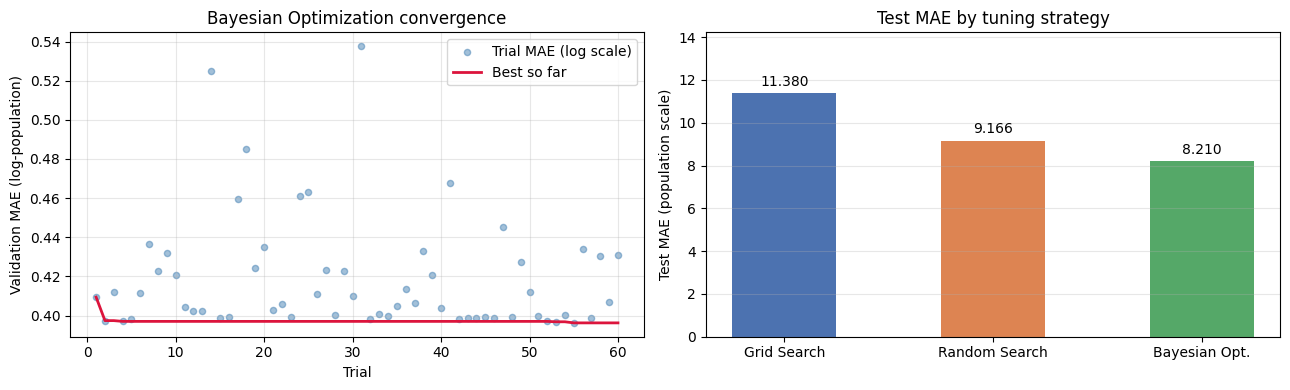

In [17]:
trial_values = [t.value for t in study.trials]
best_so_far  = np.minimum.accumulate(trial_values)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: MAE per trial + running best
ax = axes[0]
ax.scatter(range(1, len(trial_values) + 1), trial_values,
           s=20, alpha=0.5, color="steelblue", label="Trial MAE (log scale)")
ax.plot(range(1, len(best_so_far) + 1), best_so_far,
        color="crimson", linewidth=2, label="Best so far")
ax.set_xlabel("Trial")
ax.set_ylabel("Validation MAE (log-population)")
ax.set_title("Bayesian Optimization convergence")
ax.legend()
ax.grid(alpha=0.3)

# Right: bar chart comparing all three methods
ax2 = axes[1]
methods = ["Grid Search", "Random Search", "Bayesian Opt."]
maes    = [grid_metrics["MAE"], random_metrics["MAE"], bayes_metrics["MAE"]]
colors  = ["#4C72B0", "#DD8452", "#55A868"]
bars = ax2.bar(methods, maes, color=colors, width=0.5)
ax2.bar_label(bars, fmt="%.3f", padding=3, fontsize=10)
ax2.set_ylabel("Test MAE (population scale)")
ax2.set_title("Test MAE by tuning strategy")
ax2.set_ylim(0, max(maes) * 1.25)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Best model – hyperparameter importance

Analyses which hyperparameters had the largest influence on validation MAE across all Bayesian trials.

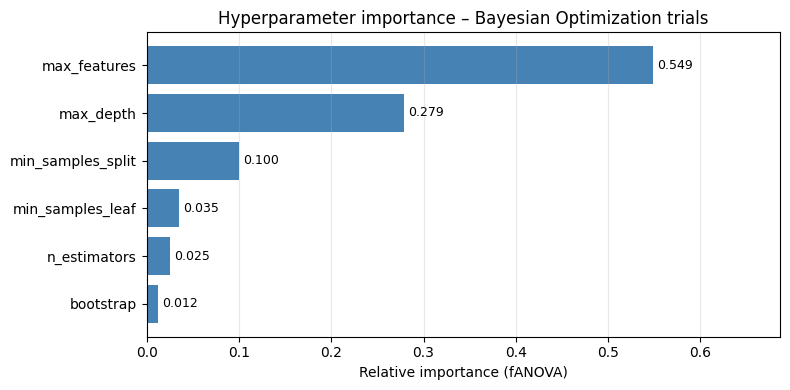

,Hyperparameter,Importance
0,max_features,0.549042
1,max_depth,0.278538
2,min_samples_split,0.100376
3,min_samples_leaf,0.034552
4,n_estimators,0.025284
5,bootstrap,0.012208


In [18]:
importances = optuna.importance.get_param_importances(study)
imp_df = pd.DataFrame(
    {"Hyperparameter": list(importances.keys()), "Importance": list(importances.values())}
).sort_values("Importance", ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(imp_df["Hyperparameter"], imp_df["Importance"], color="steelblue")
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
ax.set_xlabel("Relative importance (fANOVA)")
ax.set_title("Hyperparameter importance – Bayesian Optimization trials")
ax.set_xlim(0, imp_df["Importance"].max() * 1.25)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

display(imp_df.sort_values("Importance", ascending=False).reset_index(drop=True))

## 10. Best model – predictions vs. actuals

Scatter plot of the best model's test-set predictions against actual population values (log scale for readability).

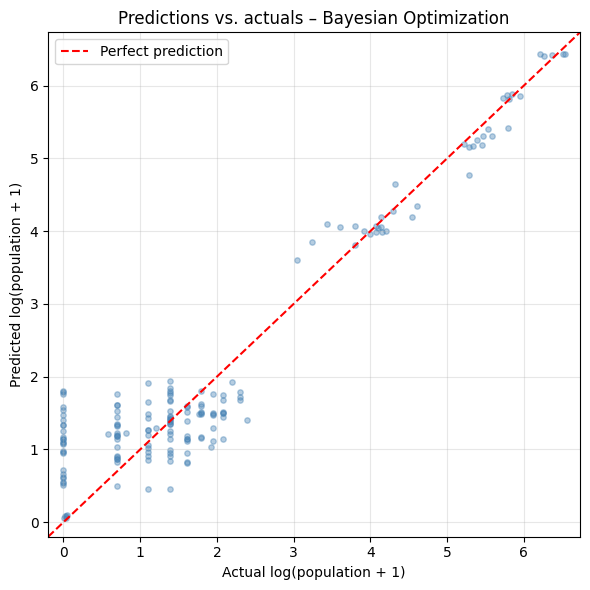

Exception ignored in: <function ResourceTracker.__del__ at 0x107290fe0>
Traceback (most recent call last):
  File "/Users/lukasbals/.pyenv/versions/3.12.11/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/Users/lukasbals/.pyenv/versions/3.12.11/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/Users/lukasbals/.pyenv/versions/3.12.11/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10bf44fe0>
Traceback (most recent call last):
  File "/Users/lukasbals/.pyenv/versions/3.12.11/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/Users/lukasbals/.pyenv/versions/3.12.11/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/Users/lukasbals/.pyenv/versions/3.12.11/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_lock

In [19]:
best_method_idx = results["MAE"].idxmin()
best_preds = [grid_preds, random_preds, bayes_preds][best_method_idx]
best_label = results.loc[best_method_idx, "Method"]

y_true_log = np.log1p(y_test.to_numpy())
y_pred_log = np.log1p(best_preds)

lims = (min(y_true_log.min(), y_pred_log.min()) - 0.2,
        max(y_true_log.max(), y_pred_log.max()) + 0.2)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_true_log, y_pred_log, alpha=0.4, s=15, color="steelblue")
ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
ax.set_xlabel("Actual log(population + 1)")
ax.set_ylabel("Predicted log(population + 1)")
ax.set_title(f"Predictions vs. actuals – {best_label}")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()